In [1]:
from dotenv import load_dotenv
import matplotlib.pyplot as plt
import networkx as nx
import getpass
import os, re, sys, time, json
from typing import TypedDict, Annotated, Sequence, Literal
from operator import add as add_messages
from langgraph.graph import StateGraph, START, END, MessagesState
from langchain_core.messages import BaseMessage, SystemMessage, HumanMessage, ToolMessage
from langchain_openai import ChatOpenAI
from langchain_openai import OpenAIEmbeddings
from langchain_community.document_loaders import PyPDFLoader
from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain_chroma import Chroma
from langchain_core.tools import tool
from langchain_tavily import TavilySearch
from typing import TypedDict, Annotated, Sequence
from operator import add as add_messages
from typing_extensions import TypedDict
from langgraph.types import Command
from langchain_community.utilities import SQLDatabase
from langchain_community.agent_toolkits import SQLDatabaseToolkit
from langchain_core.output_parsers import CommaSeparatedListOutputParser
from langgraph.prebuilt.tool_node import ToolNode
from langgraph.prebuilt import tools_condition, create_react_agent
import os
import getpass
from typing import List, Dict, Literal, TypedDict, Optional
import pandas as pd


def _set_env(var: str) -> None:
    if not os.environ.get(var):
        os.environ[var] = getpass.getpass(f"{var}: ")

class MyState(TypedDict, total=False):
    user_id: int
    messages: List[Dict[str, str]]            # {"role": "user|assistant", "content": "..."}
    profile: str                               # user 요약 정보
    rec_people: List[str]                      # 매칭 후보 id
    rec_travel: List[str]                      # 추천 여행지 id
    summary: str                               # Q&A 요약


load_dotenv(override=True)
_set_env("OPENAI_API_KEY")
PATH = "/Users/nayoung/SiNear/User_100.csv"
llm = ChatOpenAI(model="gpt-4o", temperature=0.3)

QUESTION_THEMES = [
    "여행 중 최악의 경험과 그 이유",
    "여행지에서 가장 중요하게 여기는 요소",
    "같이 여행을 가고 싶은 사람의 특징",
    "이번 여행에서 가장 기대하는 것",
    "여행 중 스트레스를 받는 순간"
]

def _build_prompt(context: str, themes: List[str]) -> str:
    themes_text = "\n".join([f"- {theme}" for theme in themes])
    
    return f"""당신은 사용자의 구체적인 여행 성향을 파악하는 전문 상담가입니다.

<목표>
아래 5가지 주제에 대해 사용자의 답변을 모두 얻어야 합니다:
{themes_text}

<현재 대화 상황>
{context}

<지침>
1. 위 대화를 분석해서 어떤 주제들이 이미 다뤄졌는지 파악하세요. 
2. 대화가 없다면, "더 구체적인 당신의 여행 성향을 파악하기 위해 몇 가지 질문을 준비했습니다. 생각나는대로 편하게 답변해주세요!" 와 함께 임의로 한 가지 주제를 정해서 질문을 시작하세요.
3. 아직 다루지 않은 주제 중에서 가장 자연스럽게 이어갈 수 있는 하나를 선택하세요.
4. 사용자의 이전 답변에 공감하며 자연스럽게 다음 질문으로 넘어가세요.

상담가의 답변: """

def chatbot_node(state: MyState) -> Command[Literal["supervisor"]]:
    """
    사용자와 5회에 걸쳐 여행 성향 대화를 나눈 뒤, 요약(summary)을 생성하는 노드.
    """
    print("\n---CHATBOT---")
    messages = state.get("messages", [])
    user_message_count = sum(1 for m in messages if m["role"] == "user")

    while user_message_count < 5:
        context = "\n".join([f"{m['role']}: {m['content']}" for m in messages])
        assistant_response = llm.invoke([
            {"role": "system", "content": _build_prompt(context, QUESTION_THEMES)}
        ]).content.strip()

        print(f"\nAssistant ▶ {assistant_response}")
        user_input = input("\nYou ▶ ").strip()

        if not user_input:
            print("입력이 비어 있습니다. 다시 입력해주세요.")
            continue

        messages.append({"role": "assistant", "content": assistant_response})
        messages.append({"role": "user", "content": user_input})
        user_message_count += 1

    # 5개의 user 메시지를 모두 받은 후 summary 생성
    time.sleep(2)
    print("\nAssistant ▶ 당신의 적극적인 답변 덕분에 당신의 여행 성향에 대해 보다 깊게 이해할 수 있게 되었어요! 이를 바탕으로 당신의 여행 메이트와 추천 여행지를 탐색해볼게요! \n")

    sys_prompt = (
        "다음 대화는 사용자의 여행 성향을 파악하기 위한 Q&A입니다.\n"
        "사용자의 답변을 한 단락으로 누락 없이 정리하세요."
    )
    llm_input = [{"role": "system", "content": sys_prompt}] + messages
    summary = llm.invoke(llm_input).content.strip()
    print(f"summary: {summary}")
    return Command(
        update={"messages": messages, "summary": summary},
        goto="supervisor",
    )

def parse_profile_output(text: str):
    """
    LLM 응답에서 중요 요소, 피하는 요소, 요약을 파싱해서 dict로 반환
    """
    important = re.search(r"(?<=- 중요 요소:).*?(?=\n- 피하는 요소:)", text, re.DOTALL)
    avoid = re.search(r"(?<=- 피하는 요소:).*?(?=\n- 요약:)", text, re.DOTALL)
    summary = re.search(r"(?<=- 요약:).*", text, re.DOTALL)

    return {
        "important": important.group(0).strip() if important else "", # 중요 요소
        "avoid": avoid.group(0).strip() if avoid else "",             # 피하는 요소
        "summary": summary.group(0).strip() if summary else ""        # 요약
    }

def profiler_node(state: MyState) -> Command[Literal["supervisor"]]:
    '''
    해당 user_id messages와 feature를 이용하여 Profile을 생성하는 에이전트입니다. 
    '''
    print("\n---PROFILER---")
    id = state['user_id']
    df = pd.read_csv(PATH)
    try:
        feature = df[df['ID'] == id].to_dict(orient="records")[0]
    except IndexError:
        feature = {}

    summary = state['summary']

    prompt = f"""
    당신은 여행 동반자 매칭 서비스를 위한 프로파일 생성 에이전트입니다.  
    다음은 한 사용자의 여행 성향에 대한 정형 데이터와, 사용자와의 대화 내용을 요약한 것입니다.

    - 여행 성향 피쳐:
    {feature}

    - 대화 요약:
    {summary}

    아래 형식을 따라, 사용자의 여행에서 중요하게 생각하는 요소(선호), 피하고 싶은 요소(기피), 그리고 이를 요약한 설명을 생성해주세요.  
    **가능하면 구체적인 항목(예: 기후, 동행자 성향, 활동 종류 등)을 명시해주세요.**

    <출력 형식>
    - 중요 요소:
    - 피하는 요소:
    - 요약:
    """

    total_profile = llm.invoke(prompt).content
    parsed = parse_profile_output(total_profile)
    print(f"profile: {parsed['summary']}")
    df.loc[df['ID'] == id, "profile"] = parsed["summary"]
    df.to_csv(PATH, index=False)

    return Command(update={"profile": parsed["summary"]}, goto= "supervisor")

def recommender_node(state: MyState, top_k=3) -> Command[Literal["supervisor"]]:
    print("\n---RECOMMENDER---")
    
    output_parser = CommaSeparatedListOutputParser()
    format_instructions = output_parser.get_format_instructions()
    
    user_id = state["user_id"]
    user_profile = state["profile"]
    df = pd.read_csv(PATH)
    others = df[(df['ID'] != user_id) & (df['profile'].notna())][['ID', 'profile']]
    
    candidate_texts = "\n".join([
        f"user_id {row.ID}: {row.profile}" for row in others.itertuples()
    ])
    
    prompt = f"""
당신은 여행 동행 추천 시스템입니다. 주어진 사용자 프로필과 다른 사용자 목록을 기반으로 가장 잘 맞는 동행자를 추천해야 합니다.

[기준 사용자 프로필]
{user_profile}

[비교할 다른 사용자 프로필 목록]
{candidate_texts}

[지시사항]
1. 기준 사용자와 다른 모든 사용자의 프로필을 비교하여 호환성을 분석하세요.
2. 호환성이 가장 높은 순서대로 상위 {top_k}명의 사용자 ID를 선정하세요.
3. 최종 응답은 아래 형식 지침을 반드시 따라야 합니다. 다른 설명은 절대 포함하지 마세요.

{format_instructions}

[최종 응답]
"""
    chain = llm | output_parser
    response_list = chain.invoke([HumanMessage(content=prompt)])
    # print(response_list)
    try:
        rec_ids = [int(item.strip()) for item in response_list]
    except (ValueError, TypeError):
        print("파서가 유효한 숫자 목록을 반환하지 못했습니다.")
        rec_ids = []

    # print(f"Output Parser로 추출한 ID 목록: {rec_ids}")

    if rec_ids:
        rec_ids = rec_ids[:top_k]

    print(f"최종 추천된 사용자 ID: {rec_ids}")

    if "rec_ids" not in df.columns:
        df["rec_ids"] = pd.Series(dtype='object')
    
    df.loc[df['ID'] == user_id, "rec_ids"] = str(rec_ids)
    df.to_csv(PATH, index=False)
    
    return Command(update={"rec_people": rec_ids}, 
                   goto="supervisor")


def supervisor_node(state: MyState) -> Command[Literal["chatbot", "profiler", "recommender", END]]:
    # print("sup")
    # print(f"Debug - summary: '{state.get('summary')}', profile: '{state.get('profile')}', rec_people: {state.get('rec_people')}")
    
    if state.get("summary") and not state.get("profile"):
        return Command(goto="profiler")
    elif state.get("profile") and not state.get("rec_people"):
        return Command(goto="recommender")
    elif state.get("rec_people"):
        return Command(goto=END)
    else:
        return Command(goto="chatbot")



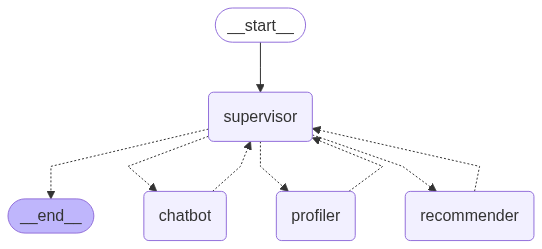

In [6]:
graph = StateGraph(MyState)
    
graph.add_node("supervisor", supervisor_node)
graph.add_node("chatbot", chatbot_node)
graph.add_node("profiler", profiler_node)
graph.add_node("recommender", recommender_node)

graph.add_edge(START, "supervisor")

app = graph.compile()
app